C:\Users\edgar\AppData\Local\Temp\ipykernel_18860\40407471.py:144: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_yscale("log")


interactive(children=(FloatLogSlider(value=1.0, description='G:', max=1.0, min=-3.0, step=0.5), FloatSlider(va…

<function __main__.update_plot(G=1, a_i=1, t_i1=1, t_s1=1, t_s2=1)>

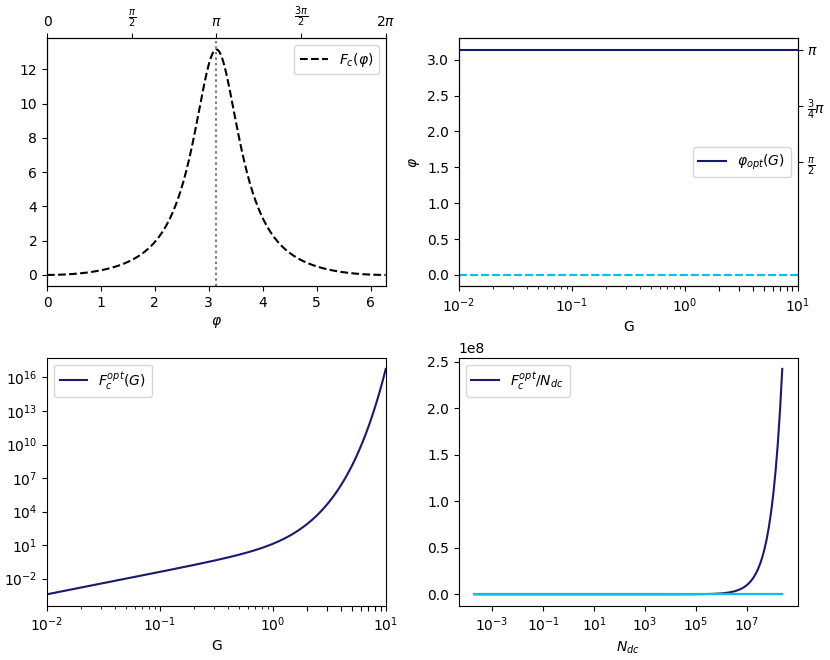

In [ ]:
%matplotlib widget
import numpy as np
from numpy import pi,abs
import matplotlib.pyplot as plt
import ipywidgets as widgets
import sys
from pathlib import Path
# Use __file__ if running as a script, or fallback to the current working directory if in Jupyter
current_dir = Path(__file__).resolve() if '__file__' in locals() else Path.cwd()
# Go up two levels to get the root directory
root_dir = current_dir.parents[1] if '__file__' in locals() else current_dir.parent
# Safely inject the directory to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
from singles import OptimalPhase, FisherInfo

phi=np.linspace(0,2*np.pi,500)
G_range=np.linspace(1e-2,10,100)

#* Fixed Phase values that will be used in the plots (with an extra zero at the end, which works as a placeholder of the optimal case)
gs=[4,2,10**(-2)]
colors=["yellowgreen","orange","deepskyblue","blueviolet"]
phases=list(np.zeros(len(gs)+1))
FeG=list(np.zeros(len(gs)+1))       #* F(G)
U=np.cosh(G_range)
V=np.sinh(G_range)

G_ticks=np.hstack((10**np.arange(np.log10(G_range.min()),0),np.arange(1,G_range.max()+1,1)))
fig, ax = plt.subplots(2,2,layout="constrained")
fig.set_figheight(6.6)
fig.set_figwidth(8.3)

line1, = ax[0,0].plot([], [], color="black", linestyle="--", label=r"$F_c(\varphi)$")
vline1 = ax[0,0].axvline(0, color="grey", linestyle=":")
vline2= ax[0,0].axvline(0, color="grey", linestyle=":")
ax[0,0].set_xlabel(r'$\varphi$')
ax[0,0].set_xlim([0, 2*pi])
ax[0,0].legend()
twin1 = ax[0,0].twiny() 
twin1.set_xlim(ax[0,0].get_xlim())
twin1.set_xticks(np.linspace(0,2*pi, 5))
twin1.set_xticklabels([0, r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])

line2, = ax[0,1].plot([], [], color="midnightblue", label=r"$\varphi_{opt}(G)$")
hlines_phi = [ax[0,1].axhline(0, color=colors[i], linestyle="--") for i in range(len(gs))]
ax[0,1].axhline(np.pi, color="grey", alpha=0)
ax[0,1].set_xlabel("G")
ax[0,1].set_ylabel(r"$\varphi$")
ax[0,1].set_xlim([G_range.min(),G_range.max()])
ax[0,1].set_xscale("log")
ax[0,1].set_xticks(G_ticks)
ax[0,1].legend()
twin2 = ax[0,1].twinx() 
twin2.set_ylim(ax[0,1].get_ylim())
twin2.set_yticks([np.pi/2,3/4*np.pi,np.pi])
twin2.set_yticklabels([r"$\frac{\pi}{2}$",r"$\frac{3}{4}\pi$",r"$\pi$"])

line3, = ax[1,0].plot([], [], color="midnightblue", label=r"$F_c^{opt}(G)$")
lines3_phi = [ax[1,0].plot([],[], color=colors[i]) for i in range(len(gs))]
test = ax[1,0].axhline(0)
ax[1,0].set_xlabel(r'G')
ax[1,0].set_xlim([G_range.min(),G_range.max()])
ax[1,0].set_xscale("log")
ax[1,0].set_xticks(G_ticks)
ax[1,0].legend()

line4, = ax[1,1].plot([], [], color="midnightblue", label=r"$F_c^{opt}/N_{dc}$")
lines4_phi = [ax[1,1].plot([],[], color=colors[i]) for i in range(len(gs))]
ax[1,1].set_xlabel(r'$N_{dc}$')
ax[1,1].set_xscale("log")
ax[1,1].legend()

def update_plot(G=1, a_i=1, t_i1=1, t_s1=1, t_s2=1):

    #? Here, the sliders will no longer represent τ. Instead, they represent T
    t_i1=np.sqrt(t_i1)
    t_s1=np.sqrt(t_s1) 
    t_s2=np.sqrt(t_s2)

    #·····················································································································
    #·····················································································································
    #·····················································································································
    
    #? Plot 1: Variable phi, fixed G value
    FeF=FisherInfo(a_i=a_i,phi=phi,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)  #*F(φ)
    phi0=OptimalPhase(a_i=a_i,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)

    #? Plot 2: Variable G
    if t_i1==1 and t_s1==1:
        U=np.cosh(G_range)
        V=np.sinh(G_range)
        phi_opt=np.pi*np.ones_like(G_range)
        phases[-1]=phi_opt
        FeG[-1]=4*abs(U)**2*abs(V)**2*(1+abs(a_i)**2)
        for i in range(len(gs)):
            hlines_phi[i].set_ydata([0])
            FeG[i]=np.zeros_like(G_range)

    else:
        phi_opt = OptimalPhase(a_i=a_i,G=G_range,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2,dps=100)
        phases[-1] = phi_opt
        for i in range(len(gs)):
            index=abs(G_range-gs[i]).argmin()
            phases[i]=phi_opt[index]
            hlines_phi[i].set_ydata([phases[i]])
        
        #? Plot 3 & 4: Variable G
        for i,phi_i in enumerate(phases):
            FeG[i]=FisherInfo(a_i=a_i,phi=phi_i,G=G_range,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)
        
    #·····················································································································
    #·····················································································································
    #·····················································································································
    
    line1.set_data(phi,FeF)
    vline1.set_xdata([phi0])
    vline2.set_xdata([2*np.pi-phi0])
    
    line2.set_data(G_range,phi_opt)
    
    line3.set_data(G_range,FeG[-1])
    for i in range(len(gs)):
        lines3_phi[i][0].set_data(G_range,FeG[i])

    U=np.cosh(G_range)
    V=np.sinh(G_range)
    Ndc=2*abs(V)**2*(1+abs(a_i)**2)+abs(a_i)**2
    line4.set_data(Ndc,FeG[-1]/Ndc)
    for i in range(len(gs)):
        lines4_phi[i][0].set_data(Ndc,FeG[i]/Ndc)
    
    ax[0,0].relim()
    ax[0,0].autoscale_view()
    ax[0,1].relim()
    ax[0,1].autoscale_view()
    ax[1,0].relim()
    ax[1,0].autoscale_view()
    ax[1,1].relim()
    ax[1,1].autoscale_view()
    twin2.set_ylim(ax[0,1].get_ylim())

ax[1,0].set_yscale("log")

G = widgets.FloatLogSlider(value=1, base=10, min=-3, max=1, step=0.5, description='G:')
a_i = widgets.FloatSlider(value=0.0, min=0, max=10, step=1, description='α:')
t_i1 = widgets.FloatSlider(value=1, min=0.1, max=1, step=0.1, description='Tᵢ₁:')
t_s1 = widgets.FloatSlider(value=1, min=0.1, max=1, step=0.1, description='Tₛ₁:')
t_s2 = widgets.FloatSlider(value=1, min=0.1, max=1, step=0.1, description='Tₛ₂:')

widgets.interact(update_plot,G=G ,a_i=a_i, t_i1=t_i1, t_s1=t_s1, t_s2=t_s2)